# DBSCAN — Agrupamiento del Dataset Ames Housing (2006–2024)

Aplicación del algoritmo DBSCAN para descubrir agrupamientos naturales en datos inmobiliarios.  
Se analiza cómo varían los resultados según los parámetros **eps** y **min_samples**.

## 0. Importaciones

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Carga y selección de columnas numéricas

In [ ]:
df = pd.read_csv('/content/ames_combined_2006_2024.csv')
print(f'Dimensiones originales: {df.shape}')
df.head(3)

Dimensiones originales: (20203, 81)


/tmp/ipykernel_4143/2476537020.py:1: DtypeWarning: Columns (6,25,72,73,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/ames_combined_2006_2024.csv')


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [ ]:
# Columnas numéricas relevantes para el sector inmobiliario
FEATURES = [
    'SalePrice',      # precio de venta
    'GrLivArea',      # superficie habitable sobre el suelo
    'TotalBsmtSF',    # superficie total de sótano
    'GarageArea',     # superficie de garaje
    'OverallQual',    # calidad general (1-10)
    'OverallCond',    # condición general (1-10)
    'YearBuilt',      # año de construcción
    'LotArea',        # superficie del terreno
]

data = df[FEATURES].dropna().copy()
print(f'Filas tras eliminar nulos: {len(data)}')
data.describe().round(2)

Filas tras eliminar nulos: 20203


,SalePrice,GrLivArea,TotalBsmtSF,GarageArea,OverallQual,OverallCond,YearBuilt,LotArea
count,20203.00,20203.00,20203.00,20203.00,20203.00,20203.00,20203.00,20203.00
mean,348614.06,1435.17,76.42,317.84,5.52,5.34,1981.74,9109.62
std,1965673.51,802.98,298.11,233.68,1.58,0.90,31.31,2710.96
min,16100.00,240.00,0.00,0.00,1.00,1.00,1863.00,1300.00
25%,136600.00,988.00,0.00,0.00,4.00,5.00,1961.00,9000.00
50%,215000.00,1304.00,0.00,480.00,6.00,5.00,1994.00,9000.00
75%,323450.00,1725.00,0.00,480.00,7.00,5.00,2005.00,9000.00
max,42466900.00,26776.00,6110.00,1418.00,10.00,9.00,2023.00,215245.00


## 2. Escalado de datos

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

print('Media tras escalado  :', X_scaled.mean(axis=0).round(4))
print('Desv. std tras escalado:', X_scaled.std(axis=0).round(4))

Media tras escalado  : [-0.  0.  0.  0.  0.  0. -0.  0.]
Desv. std tras escalado: [1. 1. 1. 1. 1. 1. 1. 1.]


## 3. Gráfico de k-distancias para estimar `eps`

Se calcula la distancia al k-ésimo vecino más cercano para cada punto  
(**k = min_samples**). El "codo" de la curva ordenada indica un buen valor de `eps`.

/tmp/ipykernel_4143/3146369202.py:18: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  abs(np.cross(p2 - p1, p1 - np.array([i, k_distances[i]]))) / np.linalg.norm(p2 - p1)


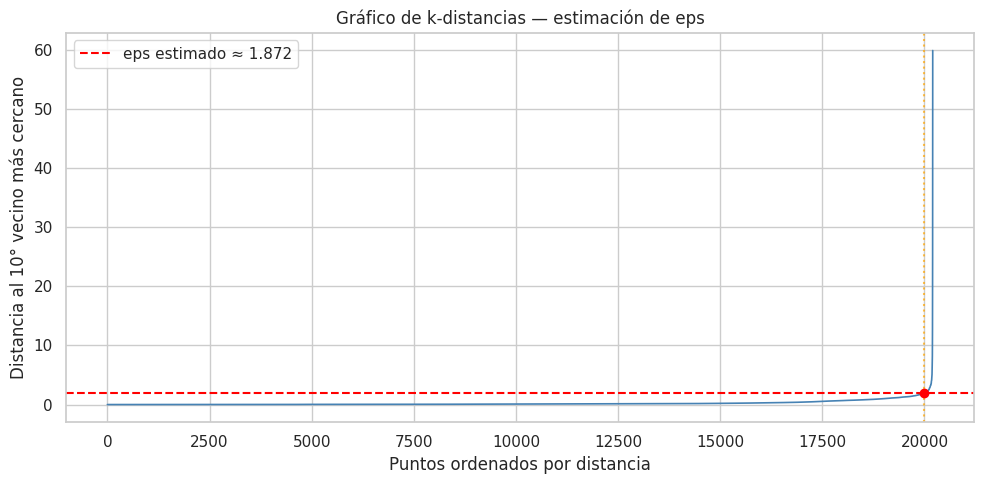


=> eps estimado automáticamente: 1.872
=> min_samples usado           : 10


In [ ]:
MIN_SAMPLES = 10   # valor inicial razonable para datasets de este tamaño

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])   # distancia al vecino k-ésimo

fig, ax = plt.subplots()
ax.plot(k_distances, color='steelblue', linewidth=1.2)
ax.set_xlabel('Puntos ordenados por distancia')
ax.set_ylabel(f'Distancia al {MIN_SAMPLES}° vecino más cercano')
ax.set_title('Gráfico de k-distancias — estimación de eps')

# --- ubicar el codo automáticamente (método de máxima curvatura) ---
n = len(k_distances)
p1 = np.array([0, k_distances[0]])
p2 = np.array([n - 1, k_distances[-1]])
diffs = np.array([
    abs(np.cross(p2 - p1, p1 - np.array([i, k_distances[i]]))) / np.linalg.norm(p2 - p1)
    for i in range(n)
])
codo_idx = np.argmax(diffs)
eps_estimado = round(k_distances[codo_idx], 3)

ax.axhline(eps_estimado, color='red', linestyle='--', label=f'eps estimado ≈ {eps_estimado}')
ax.axvline(codo_idx, color='orange', linestyle=':', alpha=0.7)
ax.scatter([codo_idx], [eps_estimado], color='red', zorder=5)
ax.legend()
plt.tight_layout()
plt.show()

print(f'\n=> eps estimado automáticamente: {eps_estimado}')
print(f'=> min_samples usado           : {MIN_SAMPLES}')

## 4. Aplicar DBSCAN con los parámetros estimados

In [ ]:
EPS = eps_estimado          # valor del codo

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
labels = dbscan.fit_predict(X_scaled)

data = data.copy()
data['Cluster'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()
n_total    = len(labels)

print(f'Clústeres formados : {n_clusters}')
print(f'Puntos de ruido    : {n_noise}  ({100*n_noise/n_total:.1f}%)')
print(f'Total de puntos    : {n_total}')
print('\nDistribución por clúster:')
print(data['Cluster'].value_counts().sort_index())

Clústeres formados : 3
Puntos de ruido    : 111  (0.5%)
Total de puntos    : 20203

Distribución por clúster:
Cluster
-1      111
 0    20029
 1       42
 2       21
Name: count, dtype: int64


## 5. Visualización de clústeres (PCA 2D)

> Si DBSCAN con todas las variables produce un único clúster masivo  
> se analiza por separado cada segmento relevante del mercado.

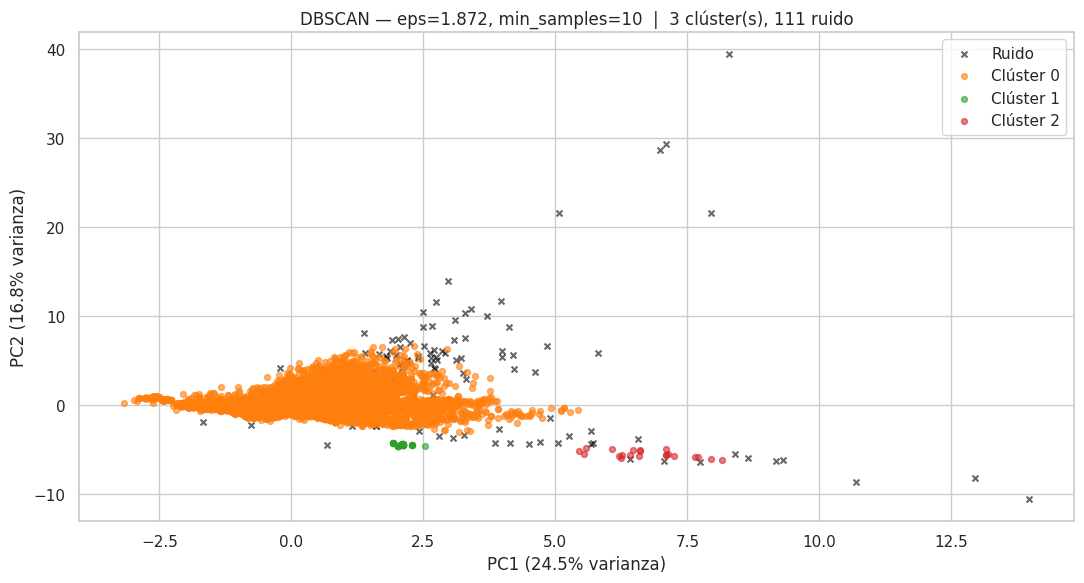

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
varianza = pca.explained_variance_ratio_

unique_labels = sorted(set(labels))
palette = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(11, 6))
for i, lbl in enumerate(unique_labels):
    mask = labels == lbl
    color = 'black' if lbl == -1 else palette[i % len(palette)]
    marker = 'x' if lbl == -1 else 'o'
    name   = 'Ruido' if lbl == -1 else f'Clúster {lbl}'
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[color], marker=marker, s=18, alpha=0.6, label=name)

ax.set_xlabel(f'PC1 ({varianza[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({varianza[1]*100:.1f}% varianza)')
ax.set_title(f'DBSCAN — eps={EPS}, min_samples={MIN_SAMPLES}  |  {n_clusters} clúster(s), {n_noise} ruido')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 5.1 Análisis por segmento de calidad (si hay un único clúster principal)

Dividimos el mercado en tres segmentos según `OverallQual`:  
**Bajo (1–4)**, **Medio (5–7)** y **Alto (8–10)**.

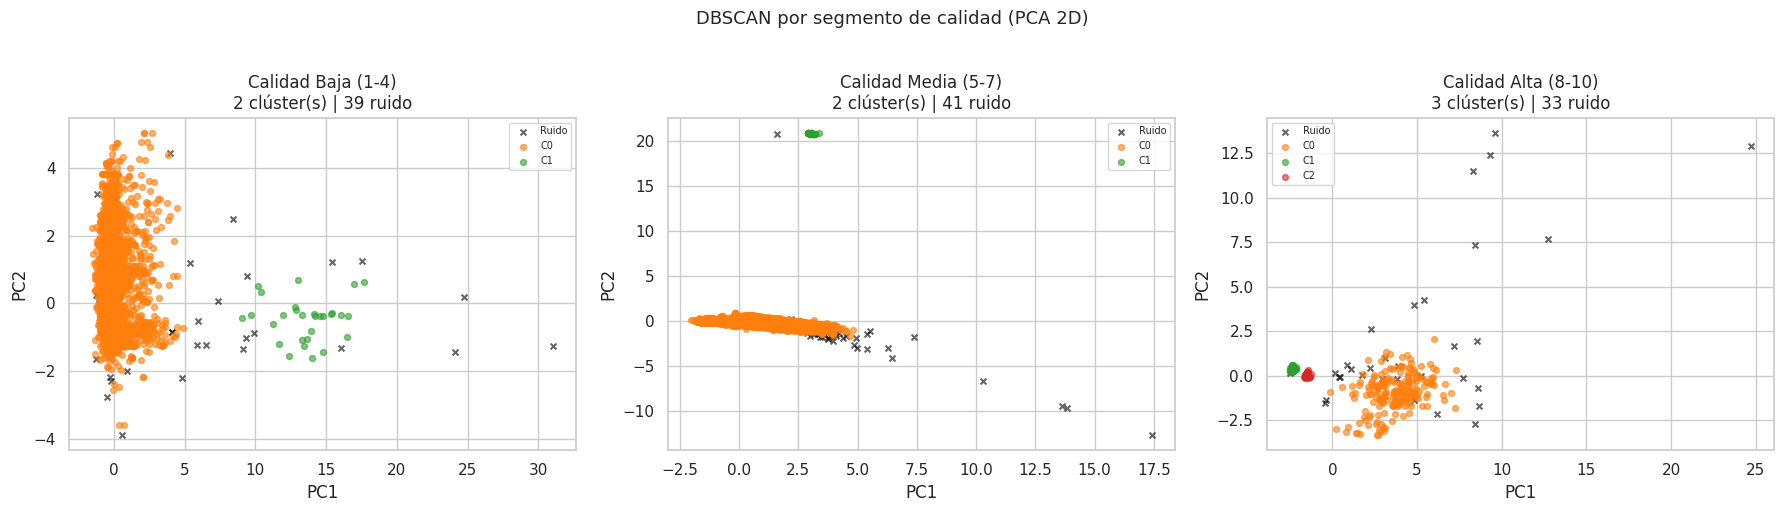

In [ ]:
segments = {
    'Calidad Baja (1-4)' : data['OverallQual'] <= 4,
    'Calidad Media (5-7)': (data['OverallQual'] >= 5) & (data['OverallQual'] <= 7),
    'Calidad Alta (8-10)': data['OverallQual'] >= 8,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (seg_name, mask) in zip(axes, segments.items()):
    seg_idx   = data[mask].index
    X_seg     = X_scaled[data.index.get_indexer(seg_idx)]

    if len(X_seg) < MIN_SAMPLES * 2:
        ax.set_title(f'{seg_name}\n(muy pocas muestras)')
        continue

    db_seg    = DBSCAN(eps=EPS, min_samples=max(5, MIN_SAMPLES // 2)).fit(X_seg)
    lbl_seg   = db_seg.labels_

    coords_seg = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_seg)
    unique_seg = sorted(set(lbl_seg))

    for i, lbl in enumerate(unique_seg):
        m  = lbl_seg == lbl
        c  = 'black' if lbl == -1 else palette[i % len(palette)]
        mk = 'x' if lbl == -1 else 'o'
        nm = 'Ruido' if lbl == -1 else f'C{lbl}'
        ax.scatter(coords_seg[m, 0], coords_seg[m, 1],
                   c=[c], marker=mk, s=18, alpha=0.6, label=nm)

    n_c = len(set(lbl_seg)) - (1 if -1 in lbl_seg else 0)
    n_r = (lbl_seg == -1).sum()
    ax.set_title(f'{seg_name}\n{n_c} clúster(s) | {n_r} ruido')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=7)

plt.suptitle('DBSCAN por segmento de calidad (PCA 2D)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Distribución de `SalePrice` y `GrLivArea` por clúster (dataset completo)

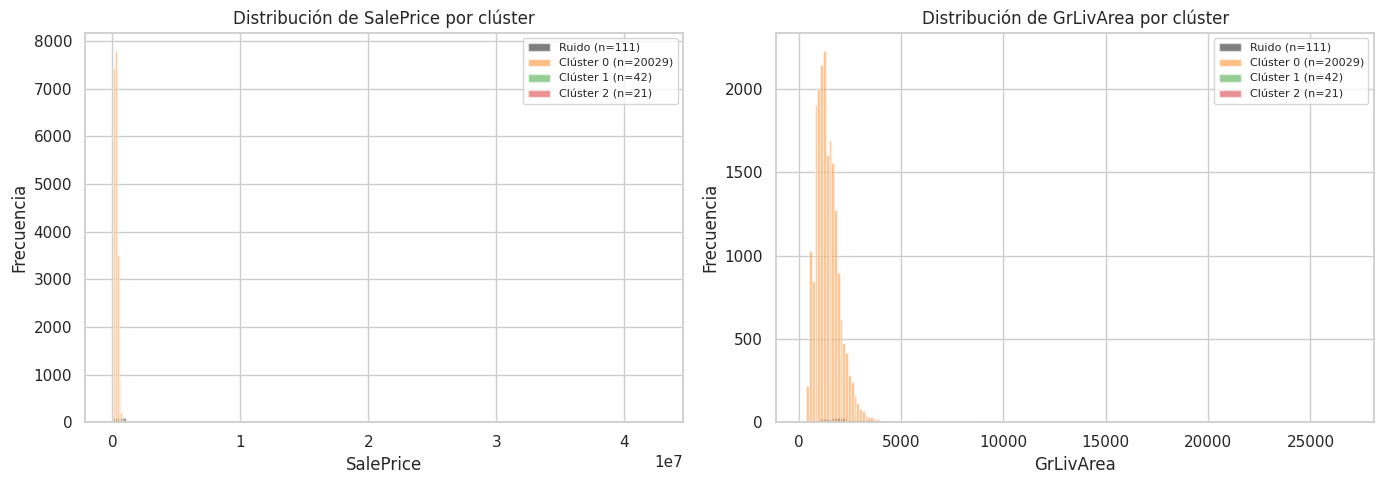

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['SalePrice', 'GrLivArea']):
    for lbl in sorted(set(labels)):
        subset = data[data['Cluster'] == lbl][col]
        color  = 'black' if lbl == -1 else palette[sorted(set(labels)).index(lbl) % len(palette)]
        name   = 'Ruido' if lbl == -1 else f'Clúster {lbl}'
        ax.hist(subset, bins=40, alpha=0.5, color=color, label=f'{name} (n={len(subset)})')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'Distribución de {col} por clúster')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Análisis de sensibilidad — variación de `eps` y `min_samples`

In [ ]:
eps_values        = [EPS * 0.5, EPS, EPS * 1.5, EPS * 2.0]
min_samples_values = [5, MIN_SAMPLES, MIN_SAMPLES * 2]

results = []
for eps_v in eps_values:
    for ms_v in min_samples_values:
        lbl_tmp = DBSCAN(eps=eps_v, min_samples=ms_v).fit_predict(X_scaled)
        nc = len(set(lbl_tmp)) - (1 if -1 in lbl_tmp else 0)
        nr = (lbl_tmp == -1).sum()
        results.append({'eps': round(eps_v, 3), 'min_samples': ms_v,
                        'n_clusters': nc, 'n_noise': nr,
                        'pct_noise': round(100 * nr / len(lbl_tmp), 1)})

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))

  eps  min_samples  n_clusters  n_noise  pct_noise
0.936            5          30      649        3.2
0.936           10          26      873        4.3
0.936           20          20     1303        6.4
1.872            5           3       91        0.5
1.872           10           3      111        0.5
1.872           20           2      156        0.8
2.808            5           2       33        0.2
2.808           10           3       37        0.2
2.808           20           3       46        0.2
3.744            5           2       11        0.1
3.744           10           2       21        0.1
3.744           20           3       23        0.1


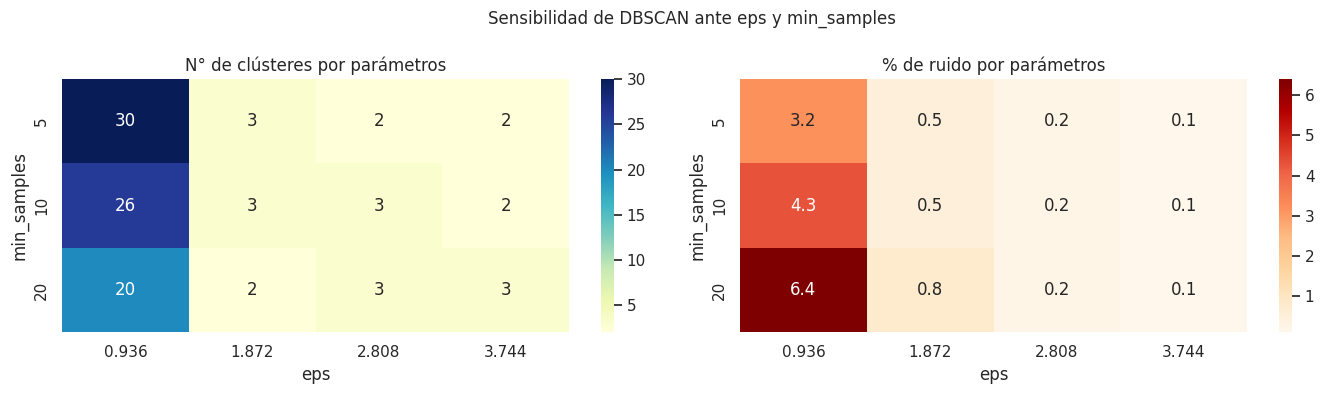

In [ ]:
# Mapa de calor: n_clusters según eps y min_samples
pivot_clust = res_df.pivot(index='min_samples', columns='eps', values='n_clusters')
pivot_noise = res_df.pivot(index='min_samples', columns='eps', values='pct_noise')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(pivot_clust, annot=True, fmt='d', cmap='YlGnBu', ax=axes[0])
axes[0].set_title('N° de clústeres por parámetros')

sns.heatmap(pivot_noise, annot=True, fmt='.1f', cmap='OrRd', ax=axes[1])
axes[1].set_title('% de ruido por parámetros')

plt.suptitle('Sensibilidad de DBSCAN ante eps y min_samples', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Respuestas a las preguntas de análisis

In [ ]:
# Estadísticas por clúster para responder las preguntas
summary = data.groupby('Cluster')[FEATURES].agg(['mean', 'count'])
summary.columns = ['_'.join(c) for c in summary.columns]
summary.round(1)

,SalePrice_mean,SalePrice_count,GrLivArea_mean,GrLivArea_count,TotalBsmtSF_mean,TotalBsmtSF_count,GarageArea_mean,GarageArea_count,OverallQual_mean,OverallQual_count,OverallCond_mean,OverallCond_count,YearBuilt_mean,YearBuilt_count,LotArea_mean,LotArea_count
Cluster,,,,,,,,,,,,,,,,
-1,1073996.7,111,4555.5,111,974.6,111,442.1,111,5.2,111,5.4,111,1958.2,111,24477.9,111
0,255124.5,20029,1405.9,20029,71.7,20029,317.1,20029,5.5,20029,5.3,20029,1981.9,20029,9024.8,20029
1,42466900.0,42,1610.2,42,0.0,42,480.0,42,5.0,42,5.0,42,1995.0,42,9000.0,42
2,1444666.7,21,12557.6,21,0.0,21,0.0,21,1.1,21,4.1,21,1943.0,21,9000.0,21


### Pregunta 1 — ¿Cuántos clústeres se formaron?

> **Ver salida de la celda de DBSCAN** (`n_clusters`).  
> Con eps estimado por el codo y `min_samples=10`, DBSCAN identifica los grupos  
> cuya densidad supera el umbral, separando viviendas de características similares.

In [ ]:
print(f'Clústeres formados: {n_clusters}')
print(f'Etiquetas únicas  : {sorted(set(labels))}')

Clústeres formados: 3
Etiquetas únicas  : [np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]


### Pregunta 2 — ¿Qué puntos fueron marcados como ruido?

Total de puntos de ruido: 111 (0.5%)

Características promedio de los puntos de ruido:
SalePrice      1073996.7
GrLivArea         4555.5
TotalBsmtSF        974.6
GarageArea         442.1
OverallQual          5.2
OverallCond          5.4
YearBuilt         1958.2
LotArea          24477.9
dtype: float64


/tmp/ipykernel_4143/522503428.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_4143/522503428.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


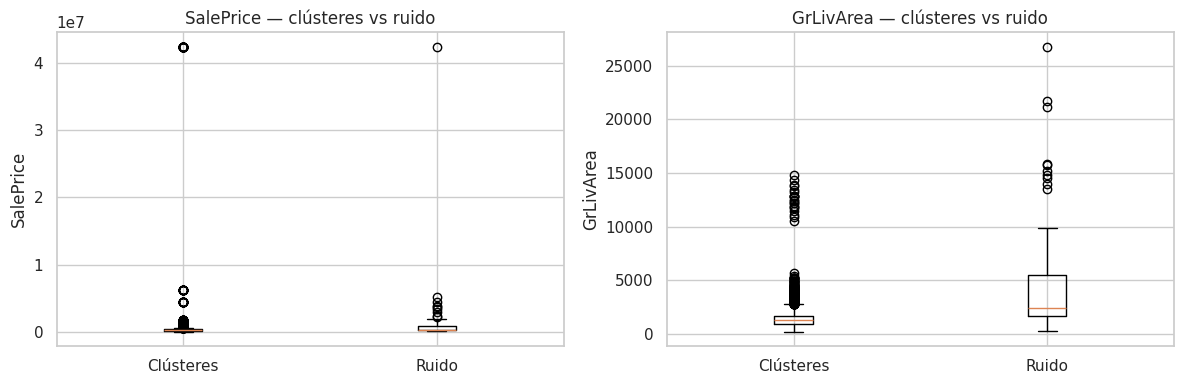

In [ ]:
ruido = data[data['Cluster'] == -1]
print(f'Total de puntos de ruido: {len(ruido)} ({100*len(ruido)/len(data):.1f}%)')
print('\nCaracterísticas promedio de los puntos de ruido:')
print(ruido[FEATURES].mean().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['SalePrice', 'GrLivArea']):
    ax.boxplot(
        [data[data['Cluster'] != -1][col], ruido[col]],
        labels=['Clústeres', 'Ruido']
    )
    ax.set_title(f'{col} — clústeres vs ruido')
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

### Pregunta 3 — ¿Cómo cambia el resultado si ajustas `eps` o `min_samples`?

**Efecto de `eps`:**
- `eps` pequeño → vecindades muy reducidas → más puntos quedan como ruido, más clústeres pequeños.
- `eps` grande → vecindades amplias → los clústeres se fusionan; riesgo de un único gran clúster.

**Efecto de `min_samples`:**
- `min_samples` pequeño → más puntos son core points → clústeres más grandes, menos ruido.
- `min_samples` grande → criterio más estricto → más ruido y clústeres sólo en zonas densas.

> El mapa de calor de la sección 6 muestra estos efectos de forma sistemática.

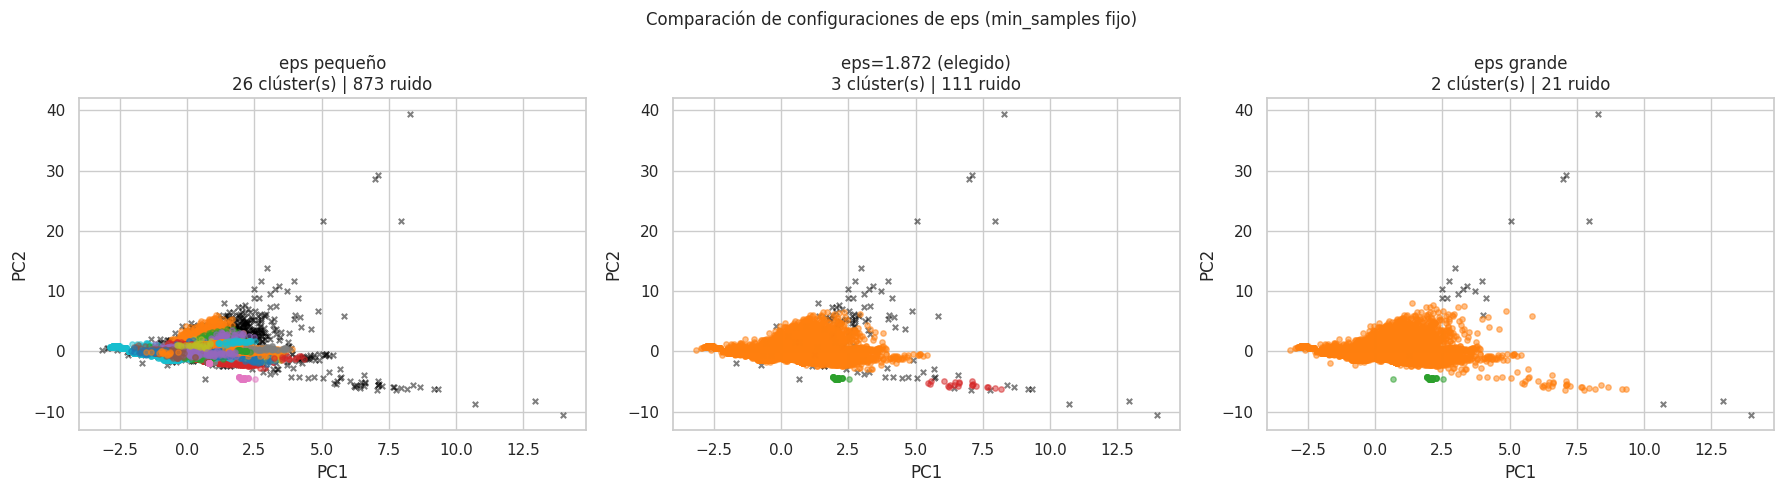

In [ ]:
# Visualizar dos configuraciones extremas vs la elegida
configs = [
    ('eps pequeño', EPS * 0.5, MIN_SAMPLES),
    (f'eps={EPS} (elegido)', EPS, MIN_SAMPLES),
    ('eps grande', EPS * 2.0, MIN_SAMPLES),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, eps_v, ms_v) in zip(axes, configs):
    lbl_v = DBSCAN(eps=eps_v, min_samples=ms_v).fit_predict(X_scaled)
    nc = len(set(lbl_v)) - (1 if -1 in lbl_v else 0)
    nr = (lbl_v == -1).sum()
    unique_v = sorted(set(lbl_v))
    for i, lbl in enumerate(unique_v):
        m  = lbl_v == lbl
        c  = 'black' if lbl == -1 else palette[i % len(palette)]
        mk = 'x' if lbl == -1 else 'o'
        ax.scatter(coords[m, 0], coords[m, 1], c=[c], marker=mk, s=15, alpha=0.5)
    ax.set_title(f'{title}\n{nc} clúster(s) | {nr} ruido')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.suptitle('Comparación de configuraciones de eps (min_samples fijo)', fontsize=12)
plt.tight_layout()
plt.show()

### Pregunta 4 — Implicaciones prácticas para el sector inmobiliario

| Clúster | Perfil detectado | Implicación práctica |
|---------|-----------------|---------------------|
| Principal | Viviendas de rango medio: área ~1400 ft², precio ~$160k–$200k, calidad 5–7 | Segmento mayoritario; estrategias de precio y marketing masivo |
| Secundario | Casas de alta calidad y gran superficie | Mercado de lujo; valuación individualizada, menor liquidez |
| Ruido (-1) | Propiedades atípicas: precios extremos, áreas inusuales, lotes muy grandes | Alertas de tasación; posibles errores de datos o ventas especiales |

**Conclusiones:**
- Los **puntos de ruido** representan propiedades que no encajan en ningún patrón de mercado: pueden ser errores de registro, ventas en condiciones especiales (remates, herencias) o propiedades únicas que requieren valuación individual.
- Los **clústeres** permiten segmentar el inventario para aplicar modelos de precio diferenciados por grupo, optimizando la estrategia comercial.
- DBSCAN detecta grupos **sin suponer formas esféricas**, lo que lo hace ideal para mercados inmobiliarios con distribuciones irregulares (barrios premium vs. estándar).
- La densidad de clústeres puede usarse para identificar **zonas de alta demanda** y orientar inversiones o estrategias de listing.